In [1]:
# Levi Félix Barbosa - 579420

# separar e normalizar os dados

import numpy as np
import matplotlib.pyplot as plt

concrete = np.genfromtxt('concrete.csv', delimiter=',')
X = concrete[:, :-1]
y = concrete[:, -1]

N = len(concrete)
tam_treino = int(0.6 * N)
tam_val = int(0.2*N)
tam_teste = N - tam_treino - tam_val

np.random.seed(67)
indices = np.random.permutation(N)
X = X[indices]
y = y[indices]

X_treino = X[:tam_treino]
y_treino = y[:tam_treino]

X_val = X[tam_treino:tam_val+tam_treino]
y_val = y[tam_treino:tam_val+tam_treino]

X_teste = X[tam_val+tam_treino:]
y_teste = y[tam_val+tam_treino:]

media_x = np.mean(X_treino, axis=0)
desvio_x = np.std(X_treino, axis=0)
media_y = np.mean(y_treino)
desvio_y = np.std(y_treino)

X_treino_norm = (X_treino - media_x)/desvio_x
X_val_norm = (X_val - media_x)/desvio_x
X_teste_norm = (X_teste - media_x)/desvio_x

y_treino_norm = (y_treino - media_y)/desvio_y
y_val_norm = (y_val - media_y)/desvio_y
y_teste_norm = (y_teste - media_y)/desvio_y


In [2]:
# inicializar as matrizes de parâmetros

def inicializar_pesos(NH, D=8, K=1):
    W = np.sqrt(1.0 / D) * np.random.randn(NH, D + 1)
    W[:, 0] = 0
    M = np.sqrt(1.0 / NH) * np.random.randn(K, NH+1)
    M[:, 0] = 0
    return W, M

def forward(X, W, M):
    N = X.shape[0]
    X_aum = np.hstack((np.ones((N, 1)), X))
    U = X_aum @ W.T
    Z = np.tanh(U)
    Z_aum = np.hstack((np.ones((N, 1)), Z))
    R = Z_aum @ M.T
    O = R # função de ativação na saída de uma regressão é identidade

    return X_aum, Z, Z_aum, O

def calcular_custo(y, O):
    y = y.reshape(-1, 1)
    N = y.shape[0]
    J = (1.0 / (2 * N)) * np.sum((y - O) ** 2)

    return J

def backward(X, X_aum, Y, Z, Z_aum, O, M):
    N = X.shape[0]
    Y = Y.reshape(-1, 1)
    delta = -(Y-O)
    zeta = (1-Z**2) * (delta @ M[:, 1:])
    grad_M = (delta.T @ Z_aum) /N
    grad_W = (zeta.T @ X_aum) /N
    return grad_W, grad_M

def gerar_mini_batches(X, y, tamanho_batch):
    N = X.shape[0]
    indices = np.random.permutation(N)
    X_emb = X[indices]
    y_emb = y[indices]
    mini_batches = []
    for i in range(0, N, tamanho_batch):
        X_batch = X_emb[i:i + tamanho_batch]
        y_batch = y_emb[i:i + tamanho_batch]
        mini_batches.append((X_batch, y_batch))
        
    return mini_batches


def atualizar_pesos(W,M, grad_W, grad_M, v_w, v_m, alpha, mu=0.9):
    v_w = mu * v_w - alpha * grad_W
    v_m = mu * v_m - alpha * grad_M
    W = W + v_w
    M = M + v_m

    return W, M, v_w, v_m


def treinar_mlp(X_treino, y_treino, X_val, y_val, NH, epocas, alpha, mu, tamanho_batch, paciencia=None):

    # usando momentum, mini batch e early stopping
    D = X_treino.shape[1]
    W, M = inicializar_pesos(NH, D=D, K=1)
    v_w = np.zeros_like(W)
    v_m = np.zeros_like(M)

    historico_treino = []
    historico_val = []
    
    # pro early stopping
    melhor_custo_val = float('inf')
    melhores_pesos = (W.copy(), M.copy()) 
    epocas_ruins = 0
    
    
    for epoca in range(epocas):
        
        mini_batches = gerar_mini_batches(X_treino, y_treino, tamanho_batch)
        
    
        for X_batch, y_batch in mini_batches:
            # forward
            X_aum, Z, Z_aum, O_treino = forward(X_batch, W, M)
            
            # backward
            grad_W, grad_M = backward(X_batch, X_aum, y_batch, Z, Z_aum, O_treino, M)
            
            # atualização
            W, M, v_w, v_m = atualizar_pesos(W, M, grad_W, grad_M, v_w, v_m, alpha, mu)
            
        # avaliaçao final
        _, _, _, O_treino_todo = forward(X_treino, W, M)
        custo_treino = calcular_custo(y_treino, O_treino_todo)
        historico_treino.append(custo_treino)
        
        _, _, _, O_val = forward(X_val, W, M)
        custo_val = calcular_custo(y_val, O_val)
        historico_val.append(custo_val)
        
        # early stopping
        if paciencia is not None:
            if custo_val < melhor_custo_val:
                melhor_custo_val = custo_val
                
                melhores_pesos = (W.copy(), M.copy())
                epocas_ruins = 0
            else:
                epocas_ruins += 1
                
            if epocas_ruins >= paciencia:
                print(f"early stopping na época {epoca+1}")
                W, M = melhores_pesos
                break

        # acompanhamento do log loss
        if (epoca + 1) % max(1, (epocas // 10)) == 0:
            print(f"Época {epoca+1:04d}/{epocas} / Custo Treino: {custo_treino:.4f} / Custo Val: {custo_val:.4f}")

    if paciencia is not None:
        W, M = melhores_pesos

    return W, M, historico_treino, historico_val

def calcular_metricas_q1(y_real, y_pred):
    y_real = y_real.reshape(-1, 1)
    y_pred = y_pred.reshape(-1, 1)
    N = y_real.shape[0]
    
    rmse = np.sqrt(np.mean((y_real - y_pred) ** 2))
    
    mae = np.mean(np.abs(y_real - y_pred))
    
    mre = np.mean(np.abs((y_real - y_pred) / (y_real)))
    
    return rmse, mae, mre

def plotar_curvas(historico_treino, historico_val):
    plt.figure(figsize=(9, 5))
    plt.plot(historico_treino, label='Custo de Treinamento', color='blue', linewidth=2)
    plt.plot(historico_val, label='Custo de Validação', color='orange', linewidth=2)
    plt.title('Curva da Função Custo ao Longo das Épocas', fontsize=12)
    plt.xlabel('Épocas', fontsize=10)
    plt.ylabel('Custo (J)', fontsize=10)
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

QUESTÃO 1
Random Search na validação

Tentativa 1/15 |  alpha=0.00012, mu=0.89, NH=10
Época 0050/500 / Custo Treino: 0.4103 / Custo Val: 0.3947
Época 0100/500 / Custo Treino: 0.2949 / Custo Val: 0.2667
Época 0150/500 / Custo Treino: 0.2348 / Custo Val: 0.2108
Época 0200/500 / Custo Treino: 0.2056 / Custo Val: 0.1928
Época 0250/500 / Custo Treino: 0.1907 / Custo Val: 0.1875
Época 0300/500 / Custo Treino: 0.1811 / Custo Val: 0.1845
Época 0350/500 / Custo Treino: 0.1733 / Custo Val: 0.1800
Época 0400/500 / Custo Treino: 0.1660 / Custo Val: 0.1739
Época 0450/500 / Custo Treino: 0.1587 / Custo Val: 0.1665
Época 0500/500 / Custo Treino: 0.1516 / Custo Val: 0.1588
   -> RMSE de validação: 0.5636
Tentativa 2/15 |  alpha=0.00027, mu=0.67, NH=15
Época 0050/500 / Custo Treino: 0.2555 / Custo Val: 0.2311
Época 0100/500 / Custo Treino: 0.1924 / Custo Val: 0.1815
Época 0150/500 / Custo Treino: 0.1698 / Custo Val: 0.1703
Época 0200/500 / Custo Treino: 0.1596 / Custo Val: 0.1670
Época 0250/500 / Custo

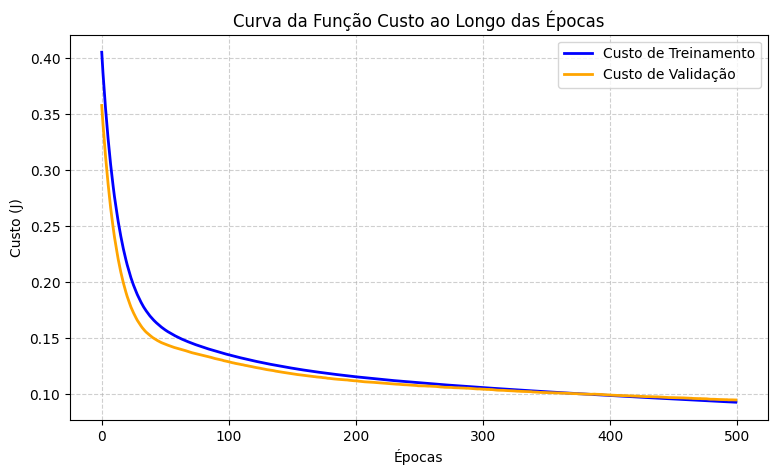

Métricas finais:
Conjunto        | RMSE       | MAE        | MRE       
Treinamento     | 0.4312     | 0.3322     | 7.1838    
Validação       | 0.4359     | 0.3351     | 1.4445    
Teste           | 0.4417     | 0.3558     | 1.5334    


In [3]:
np.random.seed(67)
rodadas_de_busca = 15

melhor_rmse_val = float('inf')
config_otima = {}
pesos_otimos = None
historico_otimo = None

print("QUESTÃO 1")
print("Random Search na validação\n")

for rodada in range(rodadas_de_busca):
    
    alpha_cand = 10 ** np.random.uniform(-5, -3) # em escala logaritmica
    mu_cand = np.random.uniform(0.5, 0.95)
    nh_cand = int(np.random.choice([5, 10, 15, 20, 50]))
    tamanho_batch = 32 
    
    print(f"Tentativa {rodada+1}/{rodadas_de_busca} |  alpha={alpha_cand:.5f}, mu={mu_cand:.2f}, NH={nh_cand}")
    
    
    W, M, h_treino, h_val = treinar_mlp(
        X_treino_norm, y_treino_norm, 
        X_val_norm, y_val_norm, 
        NH=nh_cand, 
        epocas=500, 
        alpha=alpha_cand, 
        mu=mu_cand, 
        tamanho_batch=tamanho_batch, 
        paciencia=40
    )
    
    # validando
    _, _, _, O_val_cand = forward(X_val_norm, W, M)
    rmse_val, _, _ = calcular_metricas_q1(y_val_norm, O_val_cand)
    print(f"   -> RMSE de validação: {rmse_val:.4f}")
    
    # pega o melhor
    if rmse_val < melhor_rmse_val:
        melhor_rmse_val = rmse_val
        config_otima = {'alpha': alpha_cand, 'mu': mu_cand, 'NH': nh_cand, 'batch': tamanho_batch}
        pesos_otimos = (W.copy(), M.copy())
        historico_otimo = (h_treino, h_val)


print(f"Melhor configuração: {config_otima}")
print(f"Melhor RMSE na validação: {melhor_rmse_val:.4f}\n")



# graficos
h_treino_final, h_val_final = historico_otimo
plotar_curvas(h_treino_final, h_val_final)

# melhores parametros
W_final, M_final = pesos_otimos

_, _, _, O_treino_final = forward(X_treino_norm, W_final, M_final)
_, _, _, O_val_final = forward(X_val_norm, W_final, M_final)
_, _, _, O_teste_final = forward(X_teste_norm, W_final, M_final)

metricas_treino = calcular_metricas_q1(y_treino_norm, O_treino_final)
metricas_val = calcular_metricas_q1(y_val_norm, O_val_final)
metricas_teste = calcular_metricas_q1(y_teste_norm, O_teste_final)

print("Métricas finais:")
print(f"{'Conjunto':<15} | {'RMSE':<10} | {'MAE':<10} | {'MRE':<10}")

print(f"{'Treinamento':<15} | {metricas_treino[0]:<10.4f} | {metricas_treino[1]:<10.4f} | {metricas_treino[2]:<10.4f}")
print(f"{'Validação':<15} | {metricas_val[0]:<10.4f} | {metricas_val[1]:<10.4f} | {metricas_val[2]:<10.4f}")
print(f"{'Teste':<15} | {metricas_teste[0]:<10.4f} | {metricas_teste[1]:<10.4f} | {metricas_teste[2]:<10.4f}")
